In [1]:
%%capture
!pip install -qq scikit-learn==1.7.2

In [2]:
## -- Set Device-Agnostic code --
import torch
print(f"ℹ️ Cuda available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    get_ipython().run_line_magic('load_ext', 'cuml.accel')
else:
    pass

ℹ️ Cuda available: False


In [3]:
## -- IMPORT LIBRARIES --
import sys, os, gc

## -- DATA MANIPUALATION --
import numpy as np, pandas as pd, random

## -- VISUALISATION --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
import shap

## -- FUNCTIONAL TOOLS --
from time import time, sleep
from tqdm.notebook import tqdm
from itertools import combinations, product

## -- MACHINE LEARNING --
import sklearn
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import (
                StandardScaler,
                MinMaxScaler,
                RobustScaler,
                OneHotEncoder,
                TargetEncoder as skTE
)
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.metrics import (
                roc_auc_score,
                RocCurveDisplay,
                ConfusionMatrixDisplay,
                classification_report
)

import warnings

In [4]:
print(f"sklearn version: {sklearn.__version__}")

sklearn version: 1.7.2


In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
# plt.style.use("ggplot")
sns.set_style("darkgrid")
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

COLOR = '\033[32m'
RESET = '\033[0m'

# from google.colab import data_table
# data_table.enable_dataframe_formatter()

In [6]:
### Load Data ###
PATH = '/kaggle/input/playground-series-s5e12/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop('id', axis=1)
test = pd.read_csv(PATH+"test.csv").drop('id', axis=1)

TARGET = train.columns[-1]
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

ORIG_PATH = '/kaggle/input/diabetes-health-indicators-dataset/'
orig = pd.read_csv(ORIG_PATH+'diabetes_dataset.csv')

for (name, df) in dict(Trn=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Trn shape: (700000, 25)
Test shape: (300000, 24)
Original shape: (100000, 31)

Total Numerical: 18
Total Categorical: 6
Total base features: 24


In [7]:
# ### Load Data ###
# submit = pd.read_csv("sample_submission.csv")
# train = pd.read_csv("train.csv",index_col='id') #.drop('id', axis=1)
# test = pd.read_csv("test.csv", index_col='id') #.drop('id', axis=1)

# TARGET = "loan_paid_back"
# NUMS = test.select_dtypes(include='number').columns.tolist()
# CATS = test.select_dtypes(exclude='number').columns.tolist()
# BASE = NUMS + CATS

# orig = pd.read_csv("loan_dataset_20000.csv")[BASE+[TARGET]]

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [8]:
# display(test.head())
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 25 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 700000 non-null  int64  
 1   alcohol_consumption_per_week        700000 non-null  int64  
 2   physical_activity_minutes_per_week  700000 non-null  int64  
 3   diet_score                          700000 non-null  float64
 4   sleep_hours_per_day                 700000 non-null  float64
 5   screen_time_hours_per_day           700000 non-null  float64
 6   bmi                                 700000 non-null  float64
 7   waist_to_hip_ratio                  700000 non-null  float64
 8   systolic_bp                         700000 non-null  int64  
 9   diastolic_bp                        700000 non-null  int64  
 10  heart_rate                          700000 non-null  int64  
 11  cholesterol_total         

In [9]:
train.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,62,199,58,114,102,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,71,199,50,121,124,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,73,188,59,114,108,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,74,182,54,85,123,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,85,206,49,131,124,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


# FEATURE ENGINEERING

In [10]:
# # -- Create base_risk -- 
# for df in [train, test, orig]:
#     risk_factor = (
#         0.30 * (df['age'] >= 50).astype(int) + \
#         0.10 * df['bmi'] + \
#         0.55 * (df['family_history_diabetes'] == 1).astype(int) + \
#         0.10 * (df['triglycerides'] >= 200).astype(int) + \
#         0.36 * (df['physical_activity_minutes_per_week'] >= 200).astype(int)
#     )
#     df['risk_factor'] = risk_factor

# train.iloc[:, -2:].sample(10)

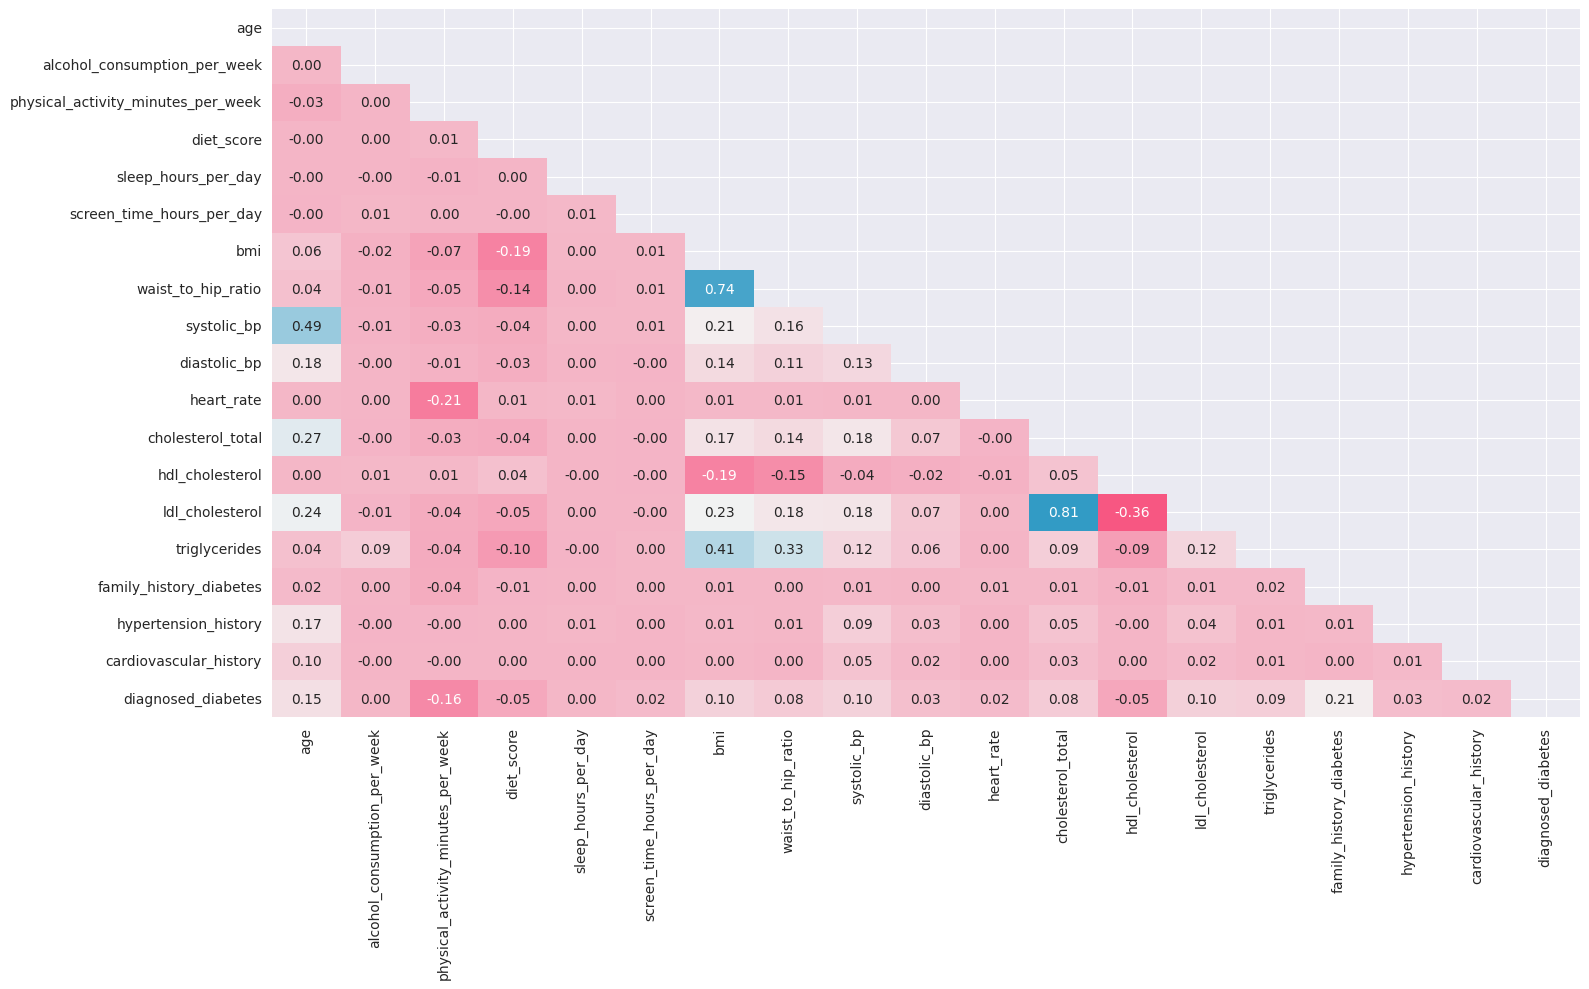

In [11]:
CORR = train.corr('spearman', numeric_only=True)

plt.figure(figsize=(16, 10))
sns.heatmap(CORR, mask=np.triu(CORR), annot=True, fmt='.2f', cmap=cmap, cbar=False)
plt.tight_layout()
plt.show()

In [12]:
# ## -- Factorize using combined data --
# for c in tqdm([i for i in CATS if train[i].dtype == 'object']):
#     combined = pd.concat([train[c], test[c], orig[c]], axis=0)
#     combined = combined.factorize()[0]

#     train[c] = combined[:len(train)].astype("int8")
#     test[c]  = combined[len(train):len(train)+len(test)].astype("int8")
#     orig[c]  = combined[-len(orig):].astype("int8")

# print('Label encoding complete!!')

In [13]:
# ## -- Use formulated feature as input --
# combine = pd.concat([train, test, orig], ignore_index=True)
# # grade_mapping = {'A': 6, 'B': 5, 'C': 4, 'D': 3, 'E': 2, 'F': 1}
# # combine['grade'] = combine['grade_subgrade'].str[0]
# # combine['grade'] = combine['grade'].map(grade_mapping)

# # combine['credit-X1-dti'] = combine['credit_score'] * (1 - combine['debt_to_income_ratio'])
# # combine['loan-income-ratio'] = combine['loan_amount'] / combine['annual_income']

# train = combine[:len(train)]
# test = combine[len(train):len(train)+len(test)]
# orig = combine[-len(orig):]

# print("Train shape:", train.shape, "Test shape:", test.shape)
# train.nunique(dropna=False).sort_values(ascending=False)

# INTERACTIONS & DIGITS | BINS

In [14]:
## -- Define categories for OHE --
CAT_COLS = [c for c in BASE if train[c].dtype=='object' or train[c].nunique() <= 0.01*len(train)]
print(f"ℹ️ Features for OHE: {len(CAT_COLS)} -> {CAT_COLS}")

ℹ️ Features for OHE: 24 -> ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [15]:
# orig.groupby('bmi')[TARGET].mean().reset_index(name='OTE_bmi_mean')

In [16]:
# orig.groupby('bmi').size().reset_index(name='OTE_bmi_count')

In [17]:
## -- Merging original features as columns --
ORIG = []

for col in tqdm(BASE):
    # MEAN
    mean_col = f"OTE_{col}_mean"
    mean_map = orig.groupby(col)[TARGET].mean().reset_index(name=mean_col)

    train = train.merge(mean_map, on=col, how='left').fillna(orig[TARGET].mean())
    test = test.merge(mean_map, on=col, how='left').fillna(orig[TARGET].mean())
    ORIG.append(mean_col)

    # COUNT
    count_col = f"OTE_{col}_count"
    count_map = orig.groupby(col).size().reset_index(name=count_col)

    train = train.merge(count_map, on=col, how='left').fillna(0)
    test = test.merge(count_map, on=col, how='left').fillna(0)
    ORIG.append(count_col)

print(len(ORIG), 'Orig Features Created!!')

  0%|          | 0/24 [00:00<?, ?it/s]

48 Orig Features Created!!


In [18]:
# ROUND = []
# for col in tqdm(['annual_income', 'loan_amount']):
#     for r in [-3, -2, -1, 0]:
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype(int)
#         test[n] = test[col].round(r).astype(int)
#         orig[n] = test[col].round(r).astype(int)
#         ROUND.append(n)

# print(f'{len(ROUND)} ROUND Features created.')
# print(train[ROUND].nunique())

# DIGITS = []
# for col in tqdm(['debt_to_income_ratio']):
#     for d in range(1, 4):
#         n = f'{col}_d{d}'
#         train[n] = ((train[col] * 10**d) % 10).fillna(-1).astype(int)
#         test[n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype(int)
#         orig[n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype(int)

#         ## -- Drop constant features --
#         if train[n].nunique() < 2:
#             train.drop([n], axis=1, inplace=True)
#             test.drop([n],  axis=1, inplace=True)
#             orig.drop([n],  axis=1, inplace=True)
#         else:
#             DIGITS.append(n)

# for col in tqdm(['interest_rate']):
#     for d in range(1, 3):
#         n = f'{col}_d{d}'
#         train[n] = ((train[col] * 10**d) % 10).fillna(-1).astype(int)
#         test[n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype(int)
#         orig[n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype(int)

#         ## -- Drop constant features --
#         if train[n].nunique() < 2:
#             train.drop([n], axis=1, inplace=True)
#             test.drop([n],  axis=1, inplace=True)
#             orig.drop([n],  axis=1, inplace=True)
#         else:
#             DIGITS.append(n)

# print(f'{len(DIGITS)} Features DIGITS extracted.')
# print(train[DIGITS].nunique())

# INTER = []
# for col1, col2 in tqdm(list(combinations(CAT_COLS+DIGITS, 2)), desc="Pairwise"):
#     new_col = f"{col1}-|-{col2}"
#     train[new_col] = train[col1].astype(str) + '_' + train[col2].astype(str)
#     test[new_col] = test[col1].astype(str) + '_' + test[col2].astype(str)
#     INTER.append(new_col)

# print(f"Ineraction Features: {len(INTER)}")

In [19]:
# def engineer_pade(df, cols):
#     # scale to [-1, 1] first so the maths doesn't explode
#     mm = MinMaxScaler(feature_range=(-1, 1))

#     for col in cols:
#         # get values
#         x = mm.fit_transform(df[[col]]).flatten()

#         # step 1: squared deviation (z-scoreish)
#         # capturing how far from 'normal' the borrower is
#         mu = np.mean(x)
#         z_sq = (x - mu)**2

#         # step 2: [2/2] pade approximant
#         # modelling the asymptotic risk curve
#         # (1 + 0.5z^2) / (1 + 0.3z^2)
#         # you may want to tune them these were where i started
#         # the epsilon is just their for safety
#         eps = 1e-6
#         num = 1.0 + 0.5 * z_sq + 0.1 * (z_sq**2)
#         den = 1.0 + 0.3 * z_sq + 0.05 * (z_sq**2) + eps

#         df[f'{col}_pade_risk'] = num / den

#         # simple reciprocal also helps with tail risk
#         df[f'{col}_recip'] = 1 / (x + 1.1)
        
#     print(f"Rational functions applied: {cols}")
#     return df

# ## -- usage
# # risk_cols = ['credit_score', 'debt_to_income_ratio', 'interest_rate', 'loan_amount']
# # df = engineer_pade(df, risk_cols)

In [20]:
# risk_cols = ['credit_score', 'debt_to_income_ratio', 'interest_rate', 'loan_amount']
# train = engineer_pade(train, risk_cols)
# test = engineer_pade(test, risk_cols)

In [21]:
# ## -> quantile cuts --
# BINS = []
# for c in tqdm(['annual_income', 'loan_amount', 'credit-X1-dti'], desc='Binning'):
#     for b in [5, 10]:
#         n = f"{c}_qbin{b}"
#         train[n], edges = pd.qcut(train[c], q=b, duplicates='drop', retbins=True, labels=False)
#         test[n] = pd.cut(test[c], bins=edges, include_lowest=True, labels=False)
#         test[n].fillna(-1, inplace=True)
#         BINS.append(n)

# print(f"Total Binned: {len(BINS)}")

# b = 6
# for c in tqdm(['annual_income','loan_amount','credit-X1-dti'], desc='Binning'):
#     n = f"{c}_bin{b}"
#     train[n], edges = pd.cut(train[c], bins=b, duplicates='drop', retbins=True, labels=False)
#     test[n] = pd.cut(test[c], bins=edges, include_lowest=True, labels=False)
#     test[n].fillna(-1, inplace=True)
#     BINS.append(n)

In [22]:
# ## -> value-based cuts --
# BINS = []
# for c in tqdm(['loan_amount'], desc='Binning'):
#     b = [0, 5000, 10000, 20000, 30000, 40000, np.inf]
#     n = f"{c}_binned"
#     train[n], edges = pd.cut(train[c], bins=b, duplicates='drop', retbins=True, labels=False)
#     test[n] = pd.cut(test[c], bins=edges, include_lowest=True, labels=False)
#     test[n].fillna(-1, inplace=True)
#     BINS.append(n)

# for c in tqdm(['annual_income'], desc='Binning'):
#     b = [0, 40000, 75000, 100000, 150000, 250000, 300000, np.inf]
#     n = f"{c}_binned"
#     train[n], edges = pd.cut(train[c], bins=b, duplicates='drop', retbins=True, labels=False)
#     test[n] = pd.cut(test[c], bins=edges, include_lowest=True, labels=False)
#     test[n].fillna(-1, inplace=True)
#     BINS.append(n)

# for c in tqdm(['credit-X1-dti'], desc='Binning'):
#     for b in [5]:
#         n = f"{c}_binned"
#         train[n], edges = pd.cut(train[c], bins=b, duplicates='drop', retbins=True, labels=False)
#         test[n] = pd.cut(test[c], bins=edges, include_lowest=True, labels=False)
#         test[n].fillna(-1, inplace=True)
#         BINS.append(n)

# print(f"Total Binned: {len(BINS)}")

# print("Train null:", train.isna().sum().sum())
# print("Test null:", test.isna().sum().sum())

In [23]:
display(train.shape, test.shape)
train.head()

(700000, 73)

(300000, 72)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes,OTE_age_mean,OTE_age_count,OTE_alcohol_consumption_per_week_mean,OTE_alcohol_consumption_per_week_count,OTE_physical_activity_minutes_per_week_mean,OTE_physical_activity_minutes_per_week_count,OTE_diet_score_mean,OTE_diet_score_count,OTE_sleep_hours_per_day_mean,OTE_sleep_hours_per_day_count,OTE_screen_time_hours_per_day_mean,OTE_screen_time_hours_per_day_count,OTE_bmi_mean,OTE_bmi_count,OTE_waist_to_hip_ratio_mean,OTE_waist_to_hip_ratio_count,OTE_systolic_bp_mean,OTE_systolic_bp_count,OTE_diastolic_bp_mean,OTE_diastolic_bp_count,OTE_heart_rate_mean,OTE_heart_rate_count,OTE_cholesterol_total_mean,OTE_cholesterol_total_count,OTE_hdl_cholesterol_mean,OTE_hdl_cholesterol_count,OTE_ldl_cholesterol_mean,OTE_ldl_cholesterol_count,OTE_triglycerides_mean,OTE_triglycerides_count,OTE_family_history_diabetes_mean,OTE_family_history_diabetes_count,OTE_hypertension_history_mean,OTE_hypertension_history_count,OTE_cardiovascular_history_mean,OTE_cardiovascular_history_count,OTE_gender_mean,OTE_gender_count,OTE_ethnicity_mean,OTE_ethnicity_count,OTE_education_level_mean,OTE_education_level_count,OTE_income_level_mean,OTE_income_level_count,OTE_smoking_status_mean,OTE_smoking_status_count,OTE_employment_status_mean,OTE_employment_status_count
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,62,199,58,114,102,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0,0.513622,1248,0.595481,26995,0.625624,601,0.578947,1406,0.597048,3591,0.602357,1612,0.699115,113.0,0.642655,2471,0.593028,2725,0.594722,4017,0.591011,3115,0.612556,1115,0.588970,3681,0.617822,1010,0.576020,809,0.548572,78059,0.592178,74920,0.595699,92080,0.598455,50216,0.593941,20103,0.600677,44891,0.603857,25150,0.600069,20176,0.601512,60175
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,71,199,50,121,124,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0,0.609855,2476,0.601681,27119,0.643436,617,0.596215,2219,0.607297,3234,0.601562,1664,0.564376,1033.0,0.580003,7331,0.615867,2710,0.585264,4791,0.610901,4770,0.612556,1115,0.618588,3626,0.623711,970,0.589686,892,0.548572,78059,0.592178,74920,0.595699,92080,0.598455,50216,0.601040,44997,0.600677,44891,0.598661,19866,0.599569,59813,0.601512,60175
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,73,188,59,114,108,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0,0.550671,1342,0.601363,17896,0.526154,325,0.590085,827,0.605560,3453,0.601942,721,0.588469,1006.0,0.580003,7331,0.535519,1098,0.626137,1209,0.594916,4367,0.617694,1266,0.564125,3462,0.617822,1010,0.570175,912,0.548572,78059,0.592178,74920,0.595699,92080,0.600657,47771,0.593941,20103,0.600677,44891,0.603857,25150,0.599569,59813,0.595285,21761
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,74,182,54,85,123,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0,0.629134,2389,0.601363,17896,0.609272,604,0.620647,1608,0.601288,3727,0.602339,684,0.603448,1044.0,0.580003,7331,0.614118,2550,0.580900,3665,0.613758,4114,0.586957,1242,0.598411,3902,0.596211,1003,0.572893,878,0.548572,78059,0.623285,25080,0.595699,92080,0.598455,50216,0.601040,44997,0.600677,44891,0.603857,25150,0.600069,20176,0.601512,60175
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,85,206,49,131,124,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0,0.629134,2389,0.595481,26995,0.642857,560,0.596215,2219,0.606158,2793,0.596564,1455,0.643338,743.0,0.633181,5455,0.565734,2358,0.590508,906,0.660440,910,0.636538,1040,0.612337,3534,0.594787,844,0.589686,892,0.548572,78059,0.623285,25080,0.595699,92080,0.600657,47771,0.601040,44997,0.600677,44891,0.598661,19866,0.599569,59813,0.595285,21761


In [24]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

In [25]:
FEATURES = [c for c in train.columns if c != TARGET]
print('Total Features', len(FEATURES))

Total Features 72


# ML TRAINING 1

In [26]:
## -- Define Training Parameters --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")
## -----------------------------------------------------------------

X = train[FEATURES]
y = train[TARGET]
models = {}

seeding = 42
SPLITS  = 10
kf = StratifiedKFold(n_splits=SPLITS, shuffle=True, random_state=SEED)

logit1 = LogisticRegression(
    max_iter = 1000,
    solver = 'lbfgs',
    C = 0.00005,
    tol = 1e-5,
    n_jobs = -1,
    random_state = seeding
)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(test))
fold_scores = []

BINARY_COLS = [c for c in CAT_COLS if train[c].nunique() == 2]
TE_COLS = [c for c in CAT_COLS if c not in BINARY_COLS]
print(f"ℹ️ Features for TE: {len(TE_COLS)} -> {TE_COLS}")

tik = time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print('|', '-'*20)
    print(f"Fold {fold+1}/{SPLITS}")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test[FEATURES].copy()

    ## -- Create pipeline --
    model = make_pipeline(
        make_column_transformer(
            (OneHotEncoder(
                handle_unknown='ignore',
                # drop='first',
            ), CAT_COLS),
            # (skTE(random_state=SEED), TE_COLS),
            remainder='passthrough',
            n_jobs=-1,
        ),
        StandardScaler(with_mean=False),
        logit1,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = y_pred
    score = roc_auc_score(y_val, y_pred)
    fold_scores.append(score)
    print(f"{COLOR}\tAUC: {score:.5f}{RESET}")

    test_preds += model.predict_proba(X_test)[:, 1] / kf.n_splits

    models['mdl1'] = model

tok = time()
tiktok = (tok-tik) / 60
print('-'*20)
print(f"\tTraining Time: {tiktok:.2f} mins{RESET}")

ℹ️ Device: CPU 4 cores
ℹ️ Features for TE: 21 -> ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']
| --------------------
Fold 1/10
	AUC: 0.73078
| --------------------
Fold 2/10
	AUC: 0.73087
| --------------------
Fold 3/10
	AUC: 0.73003
| --------------------
Fold 4/10
	AUC: 0.72888
| --------------------
Fold 5/10
	AUC: 0.73071
| --------------------
Fold 6/10
	AUC: 0.72994
| --------------------
Fold 7/10
	AUC: 0.72778
| --------------------
Fold 8/10
	AUC: 0.73168
| --------------------
Fold 9/10
	AUC: 0.73102
| --------------------
Fold 10/10
	AUC: 0.72894
--------------------
	Training Time: 16.70 mins


In [27]:
## -- After all folds --
print(f"|{'-'*52}")
overall_AUC = roc_auc_score(y, oof_preds)
features = models['mdl1'][0].get_feature_names_out(X_train.columns)
print(f" | Feature Out: {len(features)}")
print(f" | Overall AUC: {overall_AUC:.5f}")
print(f" | Average AUC: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")

print(f"|{'-'*52}")
pred_labels = (oof_preds >= 0.5).astype(int)
print(classification_report(y, pred_labels))

|----------------------------------------------------
 | Feature Out: 2090
 | Overall AUC: 0.73006
 | Average AUC: 0.73006 ± 0.00114
|----------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.63      0.41      0.50    263693
         1.0       0.71      0.85      0.77    436307

    accuracy                           0.69    700000
   macro avg       0.67      0.63      0.64    700000
weighted avg       0.68      0.69      0.67    700000



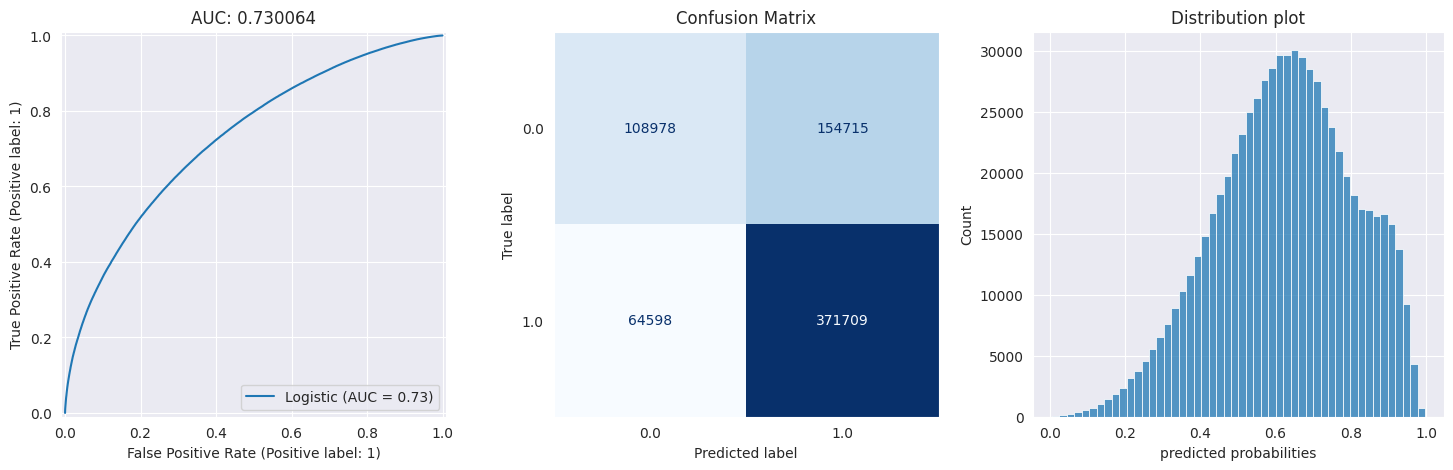

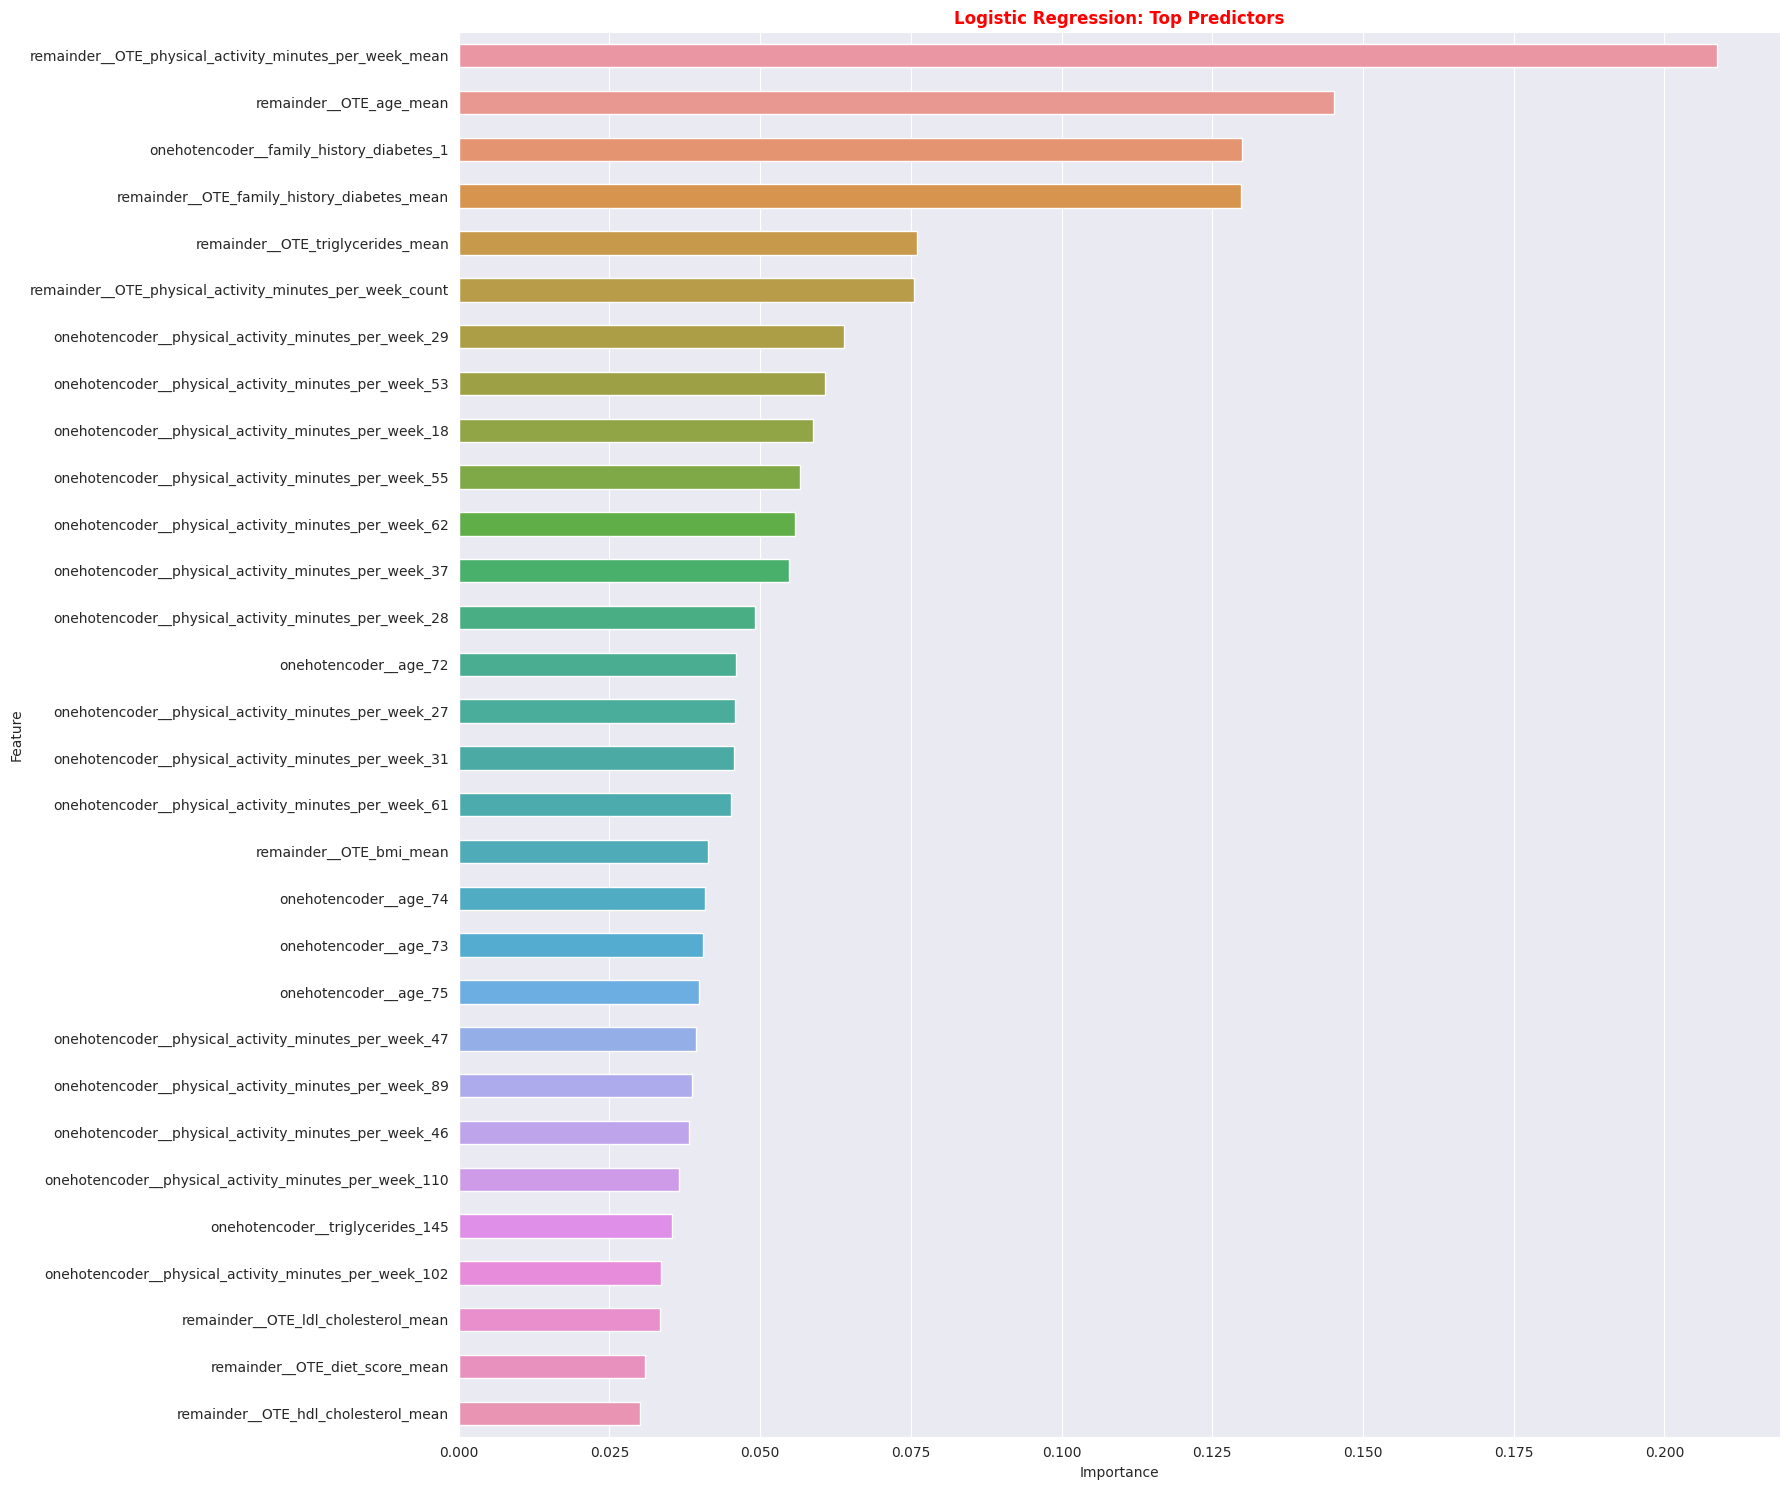

In [28]:
_, axs = plt.subplots(1, 3, figsize=(18, 5))
## -- ROC curve --
RocCurveDisplay.from_predictions(y, oof_preds, name='Logistic', ax=axs[0])
axs[0].set_title(f"AUC: {overall_AUC:.6f}")

## -- Confusion matrix (threshold = 0.5) --
ConfusionMatrixDisplay.from_predictions(y, pred_labels, cmap='Blues', colorbar=False, ax=axs[1])
axs[1].set_title(f"Confusion Matrix")
axs[1].grid(False)

## -- Distribution plot --
sns.histplot(oof_preds, bins=50, ax=axs[2])
axs[2].set_title(f"Distribution plot")
axs[2].set_xlabel(f"predicted probabilities")

## -- Plot feature importances --
plt.figure(figsize=(18, 15))
importances = models['mdl1'][-1].coef_[0]
imp = dict(Feature=features, Importance=importances)
imp_df = pd.DataFrame(imp).sort_values("Importance", ascending=False)
sns.barplot(data=imp_df.iloc[:30,:], x='Importance', y='Feature', width=0.5)
plt.title("Logistic Regression: Top Predictors", fontweight='semibold', color='r')

plt.tight_layout()
plt.show()

In [29]:
## -- Create Submissions for each model --
s = str(round(overall_AUC, 5)).split('.')[1]
np.save(f"oof_loglbf_seed{seeding}_{s}.npy", oof_preds)
np.save(f"pred_loglbf_seed{seeding}_{s}.npy", test_preds)
print(f"{COLOR}✅ oof & prediction files saved!")

submit[TARGET] = test_preds
submit.to_csv(f"submit_loglbf_{s}.csv", index=False)
print(f"{COLOR}✅ submit_loglbf_{s}.csv file saved!")

✅ oof & prediction files saved!
✅ submit_loglbf_73006.csv file saved!


# ML TRAINING 2

In [30]:
# ## -- Define Training Parameters --
# if torch.cuda.is_available():
#     print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
#     print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
# else:
#     print(f"ℹ️ Device: CPU {os.cpu_count()} cores")
# ## -----------------------------------------------------------------
# logit2 = LogisticRegression(
#     max_iter = 1000,
#     solver = 'lbfgs',
#     C = 5e-4,
#     tol = 1e-5,
#     n_jobs = -1,
#     random_state = seeding
# )

# oof_preds  = np.zeros(len(X))
# test_preds = np.zeros(len(test))
# fold_scores = []

# tik = time()
# for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
#     print('|', '-'*20)
#     print(f"Fold {fold+1}/{SPLITS}")
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
#     X_test = test[FEATURES].copy()

#     # ## -> Opt1. -> Using CUSTOM
#     # TE = TargetEncoder(cols_to_encode=INTER,cv=5,smooth=1.0,aggs=['mean'],drop_original=True)
#     # X_train = TE.fit_transform(X_train, y_train)
#     # X_val   = TE.transform(X_val)
#     # X_test  = TE.transform(X_test)

#     ## -- Create pipeline --
#     model = make_pipeline(
#         make_column_transformer(
#             (OneHotEncoder(
#                 handle_unknown='ignore',
#                 drop='first',
#             ), CAT_COLS),
#             remainder='passthrough',
#             n_jobs=-1,
#         ),
#         StandardScaler(with_mean=False),
#         logit2,
#     )
#     model.fit(X_train, y_train)

#     y_pred = model.predict_proba(X_val)[:, 1]
#     oof_preds[val_idx] = y_pred
#     score = roc_auc_score(y_val, y_pred)
#     fold_scores.append(score)
#     print(f"{COLOR}\tAUC: {score:.5f}{RESET}")
    
#     test_preds += += model.predict_proba(X_test)[:, 1] / kf.n_splits

#     models['mdl2'] = model

# tok = time()
# tiktok = (tok-tik) / 60
# print('-'*20) 
# print(f"\tTraining Time: {tiktok:.2f} mins{RESET}")

In [31]:
# ## -- After all folds --
# print(f"|{'-'*30}")
# overall_AUC = roc_auc_score(y, oof_preds)
# features = models['mdl2'][0].get_feature_names_out(X_train.columns)
# print(f"| Feature Out: {len(features)}")
# print(f"| Overall AUC: {overall_AUC:.5f}")
# print(f"| Average AUC: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")

# print(f"|{'-'*30}")
# pred_labels = (oof_preds >= 0.5).astype(int)
# print(classification_report(y, pred_labels))

In [32]:
# _, axs = plt.subplots(1, 3, figsize=(18, 5))
# ## -- ROC curve --
# RocCurveDisplay.from_predictions(y, oof_preds, name='Logistic', ax=axs[0])
# axs[0].set_title(f"AUC: {overall_AUC:.6f}")

# ## -- Confusion matrix (threshold = 0.5) --
# ConfusionMatrixDisplay.from_predictions(y, pred_labels, cmap='Blues', colorbar=False, ax=axs[1])
# axs[1].set_title(f"Confusion Matrix")
# axs[1].grid(False)

# ## -- Distribution plot --
# sns.histplot(oof_preds, bins=50, ax=axs[2])
# axs[2].set_title(f"Distribution plot")
# axs[2].set_xlabel(f"predicted probabilities")

# ## -- Plot feature importances --
# plt.figure(figsize=(18, 15))
# importances = models['mdl2'][-1].coef_[0]
# imp = dict(Feature=features, Importance=importances)
# imp_df = pd.DataFrame(imp).sort_values("Importance", ascending=False)
# sns.barplot(data=imp_df.iloc[:30,:], x='Importance', y='Feature', width=0.5)
# plt.title("Logistic Regression: Top Predictors", fontweight='semibold', color='r')

# plt.tight_layout()
# plt.show()

In [33]:
# ## -- Create Submissions for each model --
# s = str(round(overall_AUC, 5)).split('.')[1]
# np.save(f"oof_log_mdl2_seed{seeding}_{s}.npy", oof_preds)
# np.save(f"pred_log_mdl2_seed{seeding}_{s}.npy", test_preds)
# print(f"{COLOR}✅ oof & prediction files saved!")

# submit[TARGET] = test_preds
# submit.to_csv(f"submit_logistic_OHE_{s}.csv", index=False)

# print(f"{COLOR}✅ submit_logistic_OHE_{s}.csv file saved!")

# HILLCLIMB

In [34]:
# oof_df = pd.DataFrame()
# pred_df = pd.DataFrame()
# print("Loading data: ", end="")
# for (root, dirs, files) in os.walk("/kaggle/working"):
#     for i, file in enumerate(sorted(files), 1):
#         if i%20 == 0: print(f"{i}%.. ", end="")
#         if file.endswith(".npy") and "oof" in file:
#             oof_df = pd.concat([oof_df, pd.Series(np.load(os.path.join(root, file)), name=file[4:-4])], axis=1)
#         elif file.endswith(".npy") and "pred" in file:
#             pred_df = pd.concat([pred_df, pd.Series(np.load(os.path.join(root, file)), name=file[5:-4])], axis=1)

# print(COLOR)
# print(f"Total oof models : {len(oof_df.columns)}")
# print(f"Total pred models: {len(pred_df.columns)}")
# display(oof_df.head())
# display(pred_df.head())

In [35]:
# try:
#     from hillclimbers import climb_hill, partial
# except:
#     !pip install -qq -U hillclimbers
#     from hillclimbers import climb_hill, partial

In [36]:
# %%time
# trn = pd.read_csv(PATH+"train.csv").drop('id', axis=1)
# pred_hc, oof_hc = climb_hill(
#                                train = trn,
#                               target = TARGET,
#                          oof_pred_df = oof_df,
#                         test_pred_df = pred_df,
#                            objective = "maximize",
#                          eval_metric = partial(roc_auc_score),
#                     # negative_weights = True,
#                     return_oof_preds = True,
#                            precision = 0.001,
#                            plot_hill = True,
#                            plot_hist = True,
#     )

In [37]:
# print(f"Hillclimb score: {round(roc_auc_score(train[TARGET], oof_hc), 5)}")
# hc_auc = str(round(roc_auc_score(train[TARGET], oof_hc), 5)).split('.')[1]

In [38]:
# len(oof_hc), len(train[TARGET])

In [39]:
# np.save(f"oof_log-hc_seed{seeding}.npy", oof_hc)
# np.save(f"pred_log-hc_seed{seeding}.npy", pred_hc)

In [40]:
# submit[TARGET] = pred_hc
# submit.to_csv(f"submit_HC-log-seed{seeding}_{hc_auc}.csv", index=False)
# print(f"✅ Saved hillclimb predictions!!!")
# submit.head()

In [41]:
# len(oof_hc), len(pred_hc)